<a href="https://colab.research.google.com/github/KrishnaMohan67/studentPerformancePrediction/blob/main/StudentPerformancePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
 #Import Pandas for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for creating graphs
import matplotlib.pyplot as plt

# Import Seaborn for advanced data visualization
import seaborn as sns

# Import train_test_split to divide the dataset into training and testing data
from sklearn.model_selection import train_test_split

# Import regression algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Import evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Ignore unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load the Student Performance Updated Dataset
# Make sure the CSV file is uploaded to Google Colab

df = pd.read_csv("/content/sample_data/student_performance_updated_1000.csv")

# Display the first five records
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [ ]:
# Display the number of rows and columns
print("Dataset Shape:", df.shape)

# Display the column names
print("\nColumn Names:")
print(df.columns.tolist())

# Display information about data types and non-null values
print("\nDataset Information:")
df.info()

# Display basic statistical information
print("\nStatistical Summary:")
df.describe()

Dataset Shape: (1000, 12)

Column Names:
['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Stu

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


In [ ]:
# StudentID and Name are identifiers and do not provide useful
# information for predicting the student's exam score.

df = df.drop(['Name', 'StudentID'], axis=1)

# Display the updated dataset shape
print("Shape after removing irrelevant columns:", df.shape)

# Display the remaining columns
print("\nRemaining Columns:")
print(df.columns.tolist())

Shape after removing irrelevant columns: (1000, 10)

Remaining Columns:
['Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken']


In [ ]:
# Count the number of missing values in each column

missing_values = df.isnull().sum()

print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Gender                       48
AttendanceRate               40
StudyHoursPerWeek            50
PreviousGrade                33
ExtracurricularActivities    43
ParentalSupport              22
FinalGrade                   40
Study Hours                  24
Attendance (%)               41
Online Classes Taken         25
dtype: int64


In [ ]:
# Remove rows containing missing values
# This ensures that the ML models receive complete records.

df = df.dropna()

# Display the shape after removing missing values
print("Shape after handling missing values:", df.shape)

# Check whether any missing values remain
print("\nRemaining Missing Values:")
print(df.isnull().sum())

Shape after handling missing values: (695, 10)

Remaining Missing Values:
Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
FinalGrade                   0
Study Hours                  0
Attendance (%)               0
Online Classes Taken         0
dtype: int64


In [ ]:
# Check the number of duplicate records in the dataset

duplicates = df.duplicated().sum()

print("Number of duplicate records:", duplicates)

# Remove duplicates if any are present
df = df.drop_duplicates()

print("Dataset Shape after removing duplicates:", df.shape)

Number of duplicate records: 0
Dataset Shape after removing duplicates: (695, 10)


In [ ]:
# Convert the Gender column from text into numerical values
# Male = 0
# Female = 1

df['Gender'] = df['Gender'].map({
    'Male': 0,
    'Female': 1
})

# Convert ParentalSupport into numerical values
# Low = 0
# Medium = 1
# High = 2

df['ParentalSupport'] = df['ParentalSupport'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

# Convert Online Classes Taken into integer values
df['Online Classes Taken'] = df['Online Classes Taken'].astype(int)

# Display the first five processed records
df.head()

,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,0,85.0,15.0,78.0,1.0,2,80.0,4.8,59.0,0
1,1,90.0,20.0,85.0,2.0,1,87.0,2.2,70.0,1
2,0,78.0,10.0,65.0,0.0,0,68.0,4.6,92.0,0
3,0,92.0,25.0,90.0,3.0,2,92.0,2.9,96.0,0
6,0,70.0,8.0,60.0,0.0,0,62.0,4.5,96.0,0


In [ ]:
# Check the final dataset information after preprocessing

print("Final Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nFirst Five Records:")
display(df.head())

Final Dataset Shape: (695, 10)

Data Types:
Gender                         int64
AttendanceRate               float64
StudyHoursPerWeek            float64
PreviousGrade                float64
ExtracurricularActivities    float64
ParentalSupport                int64
FinalGrade                   float64
Study Hours                  float64
Attendance (%)               float64
Online Classes Taken           int64
dtype: object

First Five Records:


,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,0,85.0,15.0,78.0,1.0,2,80.0,4.8,59.0,0
1,1,90.0,20.0,85.0,2.0,1,87.0,2.2,70.0,1
2,0,78.0,10.0,65.0,0.0,0,68.0,4.6,92.0,0
3,0,92.0,25.0,90.0,3.0,2,92.0,2.9,96.0,0
6,0,70.0,8.0,60.0,0.0,0,62.0,4.5,96.0,0


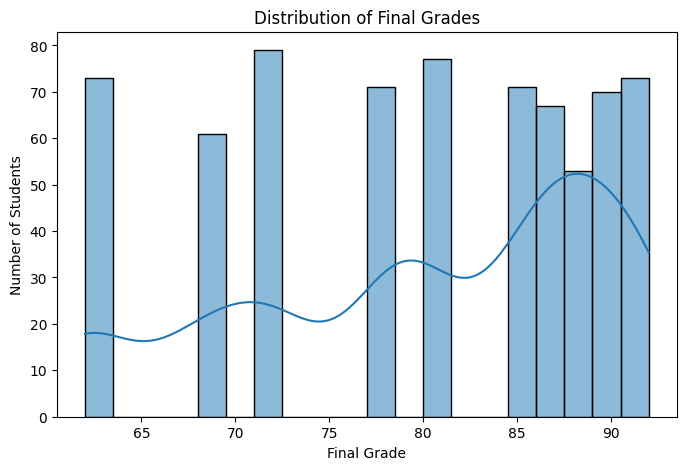

In [ ]:
# Plot the distribution of students' final grades

plt.figure(figsize=(8, 5))

sns.histplot(df['FinalGrade'], bins=20, kde=True)

plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")

plt.show()

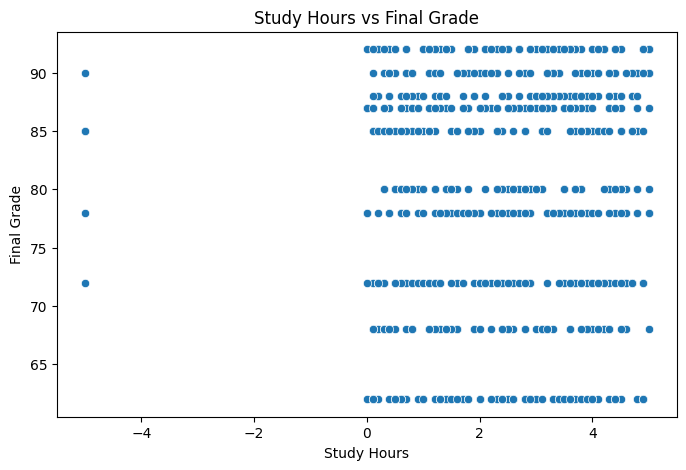

In [ ]:
# Analyze the relationship between study hours and final grade

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df['Study Hours'],
    y=df['FinalGrade']
)

plt.title("Study Hours vs Final Grade")
plt.xlabel("Study Hours")
plt.ylabel("Final Grade")

plt.show()

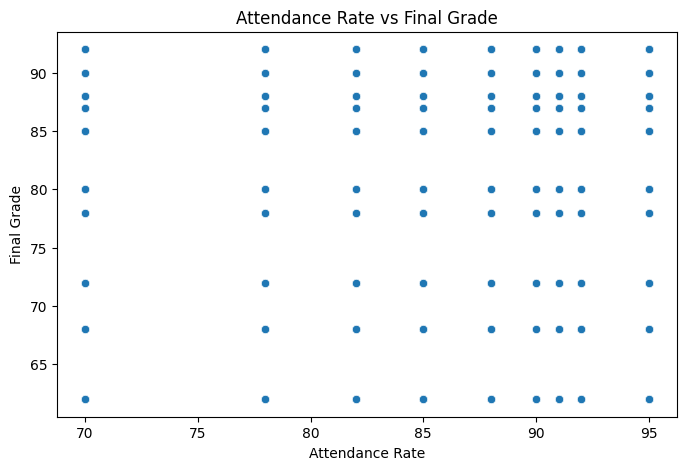

In [ ]:
# Analyze the relationship between attendance and final grade

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=df['AttendanceRate'],
    y=df['FinalGrade']
)

plt.title("Attendance Rate vs Final Grade")
plt.xlabel("Attendance Rate")
plt.ylabel("Final Grade")

plt.show()

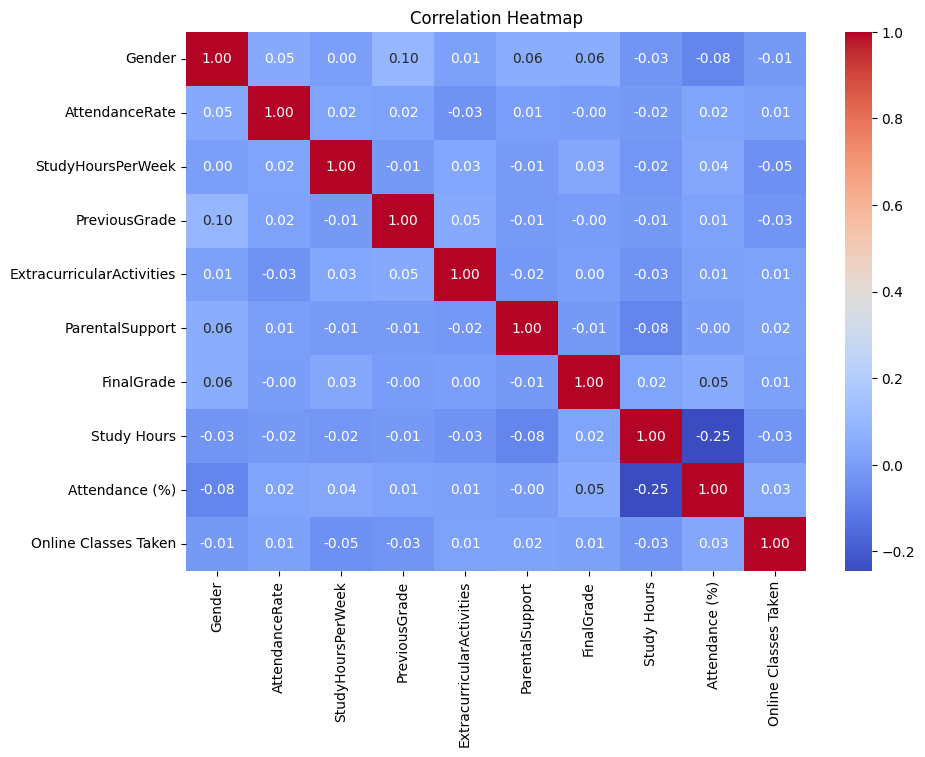

In [ ]:
# Calculate the correlation matrix for all numerical variables

correlation_matrix = df.corr()

# Create the correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
# Select the input features used to predict the final exam score

X = df.drop('FinalGrade', axis=1)

# Select FinalGrade as the target variable

y = df['FinalGrade']

# Display the feature names
print("Input Features:")
print(X.columns.tolist())

print("\nTarget Variable:")
print("FinalGrade")

Input Features:
['Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'Study Hours', 'Attendance (%)', 'Online Classes Taken']

Target Variable:
FinalGrade


In [ ]:
# Split the dataset into training and testing sets
# 80% of the data is used for training
# 20% of the data is used for testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display the sizes of training and testing datasets

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (556, 9)
Testing Data: (139, 9)


In [ ]:
# Create the machine learning regression models

models = {

    # Linear Regression provides a simple baseline model
    "Linear Regression": LinearRegression(),

    # Decision Tree can capture non-linear relationships
    "Decision Tree": DecisionTreeRegressor(
        max_depth=5,
        random_state=42
    ),

    # Random Forest combines multiple decision trees
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),

    # Gradient Boosting builds models sequentially
    # to improve prediction errors
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

print("Models created successfully.")

Models created successfully.


In [ ]:
# Dictionary to store predictions from each model
predictions = {}

# Train every model using the training dataset

for name, model in models.items():

    # Train the model
    model.fit(X_train, y_train)

    # Predict final grades for the test dataset
    y_pred = model.predict(X_test)

    # Store predictions
    predictions[name] = y_pred

    print(name, "trained successfully.")

Linear Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [ ]:
# Create a list to store model evaluation results

results = []

# Evaluate each trained model

for name, y_pred in predictions.items():

    # Calculate Mean Absolute Error
    mae = mean_absolute_error(y_test, y_pred)

    # Calculate Mean Squared Error
    mse = mean_squared_error(y_test, y_pred)

    # Calculate Root Mean Squared Error
    rmse = np.sqrt(mse)

    # Calculate R² Score
    r2 = r2_score(y_test, y_pred)

    # Store the results
    results.append([
        name,
        mae,
        mse,
        rmse,
        r2
    ])

# Convert results into a DataFrame

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "MSE",
        "RMSE",
        "R2 Score"
    ]
)

# Display the model comparison table

results_df

,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,8.143873,90.857587,9.531925,0.001180
1,Decision Tree,8.625909,111.951026,10.580691,-0.230705
2,Random Forest,8.186530,91.892748,9.586071,-0.010199
3,Gradient Boosting,8.535900,97.962978,9.897625,-0.076931


In [ ]:
# Select the model with the highest R² Score

best_model_name = results_df.loc[
    results_df['R2 Score'].idxmax(),
    'Model'
]

# Get the actual best model
best_model = models[best_model_name]

print("Best Performing Model:")
print(best_model_name)

# Display its performance
best_result = results_df[
    results_df['Model'] == best_model_name
]

print("\nPerformance:")
display(best_result)

Best Performing Model:
Linear Regression

Performance:


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,8.143873,90.857587,9.531925,0.00118


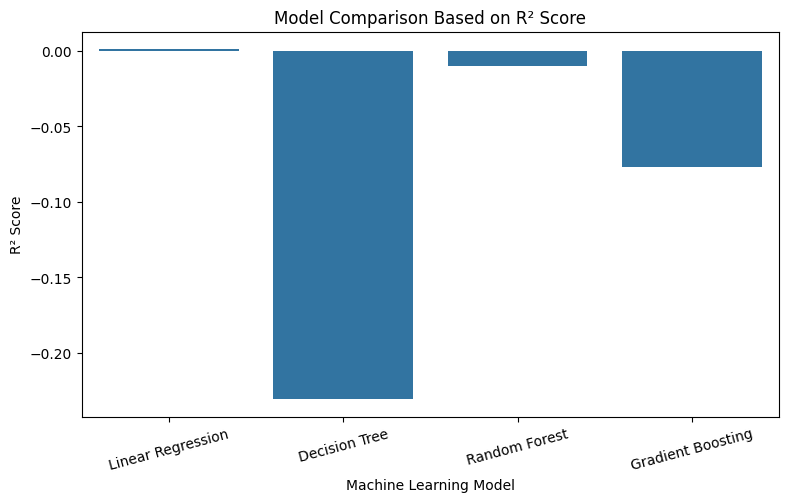

In [ ]:
# Compare the R² scores of all machine learning models

plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2 Score'
)

plt.title("Model Comparison Based on R² Score")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.show()

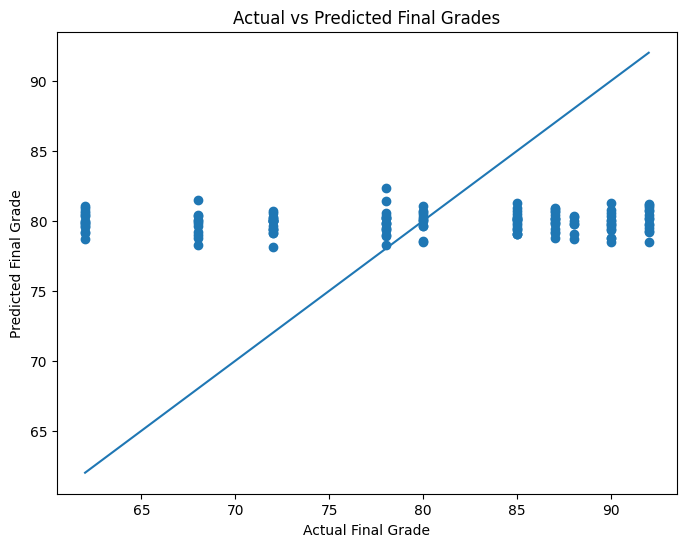

In [ ]:
# Get predictions from the best-performing model

best_predictions = predictions[best_model_name]

# Create a scatter plot comparing actual and predicted scores

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions
)

# Add a reference line representing perfect predictions

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.title("Actual vs Predicted Final Grades")
plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")

plt.show()

In [ ]:
# Create sample input for a new student
# The values should follow the same feature order as X.columns

new_student = pd.DataFrame([{
    'Gender': 1,
    'AttendanceRate': 90,
    'StudyHoursPerWeek': 20,
    'PreviousGrade': 85,
    'ExtracurricularActivities': 2,
    'ParentalSupport': 2,
    'Study Hours': 5,
    'Attendance (%)': 90,
    'Online Classes Taken': 1
}])

# Make sure the feature order is exactly the same as the training data

new_student = new_student[X.columns]

# Predict the exam score using the selected model

predicted_score = best_model.predict(new_student)[0]

print("Predicted Student Exam Score:", round(predicted_score, 2))

Predicted Student Exam Score: 81.12


In [ ]:
# Display a final summary of the project

print("==========================================")
print(" STUDENT EXAM SCORE PREDICTION")
print("==========================================")

print("Original Dataset Records : 1000")
print("Processed Dataset Records:", len(df))

print("\nBest Performing Model:")
print(best_model_name)

print("\nBest Model Performance:")
print(best_result.to_string(index=False))

print("\nPredicted Score for New Student:",
      round(predicted_score, 2))

 STUDENT EXAM SCORE PREDICTION
Original Dataset Records : 1000
Processed Dataset Records: 695

Best Performing Model:
Linear Regression

Best Model Performance:
            Model      MAE       MSE     RMSE  R2 Score
Linear Regression 8.143873 90.857587 9.531925   0.00118

Predicted Score for New Student: 81.12
